# Metodologia Design Science Research (DSR)

**Etapa de Pesquisa (Peffers et al., 2007):**
### 5. Avaliação (Evaluation) e 6. Comunicação (Communication)

**Objetivo Acadêmico:** Este notebook representa a etapa de alta performance do artefato. Utilizamos algoritmos de *Gradient Boosting* (XGBoost, LightGBM, CatBoost) para maximizar a precisão preditiva. Além disso, incorporamos a **Explicabilidade de IA (XAI)** via SHAP Values. Segundo a Indústria 5.0, a colaboração humano-máquina exige que os modelos sejam transparentes e auditáveis (Hevner et al., 2004). O uso de SHAP permite transformar a "caixa-preta" do boosting em um sistema de suporte à decisão compreensível pelo gestor da UAN.


# 07e - Modelagem: Gradient Boosting (Otimizado para Estabilidade)
Neste notebook, aplicamos modelos de Boosting focando na **estabilidade**, ignorando variáveis ruidosas que foram prejudicadas pelo gap de dados em Julho.

**Estratégia**: Em vez de centenas de variáveis complexas, focaremos no sinal mais forte: **total_reservas** e variáveis de calendário estáveis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
import shap
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import joblib
import os

# Configurações
BASE_SELECIONADA = '../data/base_features_selecionadas.csv'
TARGET = 'total_servido'

df = pd.read_csv(BASE_SELECIONADA)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')

print(f"📦 Base carregada: {df.shape[0]} registros.")

📦 Base carregada: 92 registros.


In [2]:
# 1. Divisão Treino/Teste (Temporal)
train_size = int(len(df) * 0.8)

# 2. Seleção de Variáveis (Foco em Sinais Reais)
# O gap de 27 dias invalidou lags longos. Vamos usar as Top 5 mais correlacionadas Recentemente.
top_5_features = ['total_reservas', 'dia_semana', 'etapa_acad_3', 'etapa_acad_2', 'total_reservas_lag_3']
print(f"📌 Forçando as Top 5 Features Estáveis: {top_5_features}")

X = df[top_5_features]
y = df[TARGET]

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"📈 Treino: {len(X_train)} dias | Teste: {len(X_test)} dias")

📌 Forçando as Top 5 Features Estáveis: ['total_reservas', 'dia_semana', 'etapa_acad_3', 'etapa_acad_2', 'total_reservas_lag_3']
📈 Treino: 73 dias | Teste: 19 dias


In [3]:
# Otimizando os 3 grandes do Boosting
models_params = {
    'XGBoost': {
        'model': XGBRegressor(random_state=42, objective='reg:absoluteerror'),
        'params': {
            'n_estimators': [100, 300],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7]
        }
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, verbose=-1, metric='mae'),
        'params': {
            'n_estimators': [100, 300],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [20, 31, 50]
        }
    },
    'CatBoost': {
        'model': CatBoostRegressor(random_state=42, verbose=0, loss_function='MAE'),
        'params': {
            'iterations': [100, 300],
            'learning_rate': [0.01, 0.05, 0.1],
            'depth': [4, 6, 8]
        }
    }
}

results = []
best_estimators = {}

for name, config in models_params.items():
    print(f"🔄 Otimizando {name}...")
    grid = GridSearchCV(config['model'], config['params'], cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    
    preds = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        'Modelo': name, 
        'MAE': mae, 
        'RMSE': rmse, 
        'R2': r2, 
        'Best_Params': grid.best_params_
    })

df_results = pd.DataFrame(results).sort_values('MAE')
display(df_results)

🔄 Otimizando XGBoost...


🔄 Otimizando LightGBM...


🔄 Otimizando CatBoost...


,Modelo,MAE,RMSE,R2,Best_Params
1,LightGBM,26.343649,39.801209,-0.039928,"{'learning_rate': 0.05, 'n_estimators': 100, '..."
2,CatBoost,26.871111,38.439669,0.030004,"{'depth': 6, 'iterations': 100, 'learning_rate..."
0,XGBoost,27.308304,40.565541,-0.080253,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


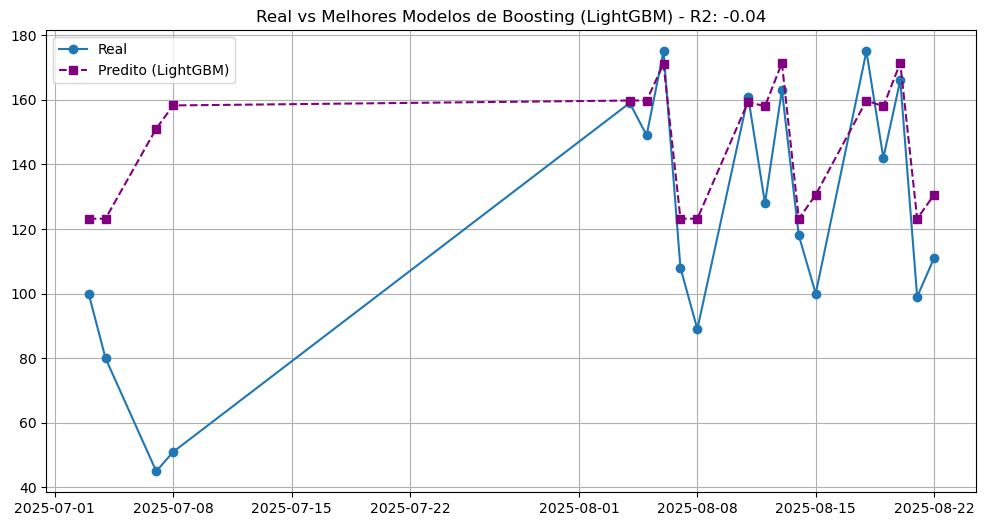

In [4]:
best_name = df_results.iloc[0]['Modelo']
best_model = best_estimators[best_name]
final_preds = best_model.predict(X_test)

plt.figure(figsize=(12, 6))
plt.plot(df.iloc[train_size:]['data'], y_test, label='Real', marker='o')
plt.plot(df.iloc[train_size:]['data'], final_preds, label=f'Predito ({best_name})', linestyle='--', marker='s', color='purple')
plt.title(f"Real vs Melhores Modelos de Boosting ({best_name}) - R2: {df_results.iloc[0]['R2']:.2f}")
plt.legend()
plt.grid(True)
plt.show()

## Explainable AI (XAI) - SHAP Values
Utilizamos o SHAP (*SHapley Additive exPlanations*) para entender a contribuição de cada variável na previsão final. Isso garante a transparência do modelo conforme os princípios da Indústria 5.0.

🔍 Calculando SHAP Values para o modelo: LightGBM


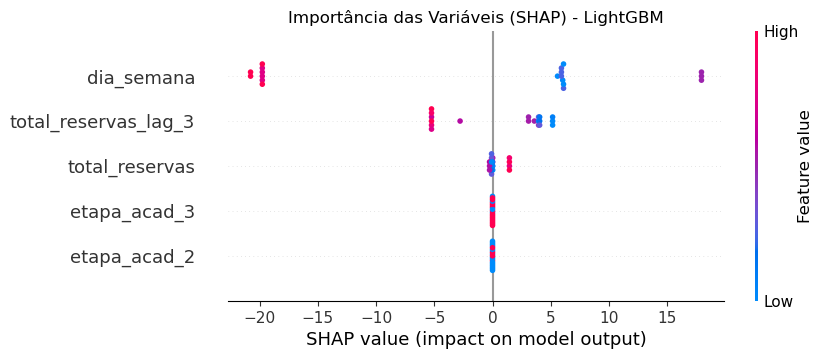

In [5]:
# Inicializa o explicador SHAP para o melhor modelo
print(f"🔍 Calculando SHAP Values para o modelo: {best_name}")
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

# Plot Summary (Beeswarm)
plt.title(f"Importância das Variáveis (SHAP) - {best_name}")
shap.plots.beeswarm(shap_values, show=False)
plt.show()

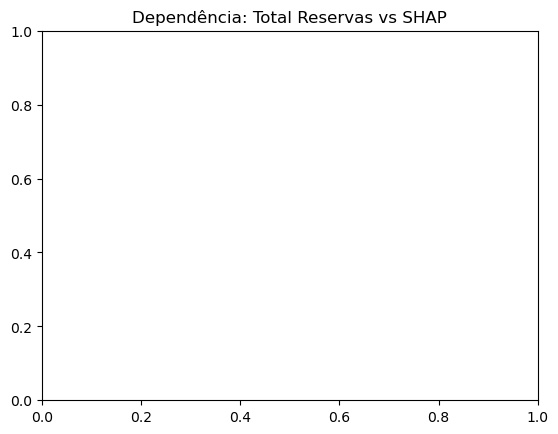

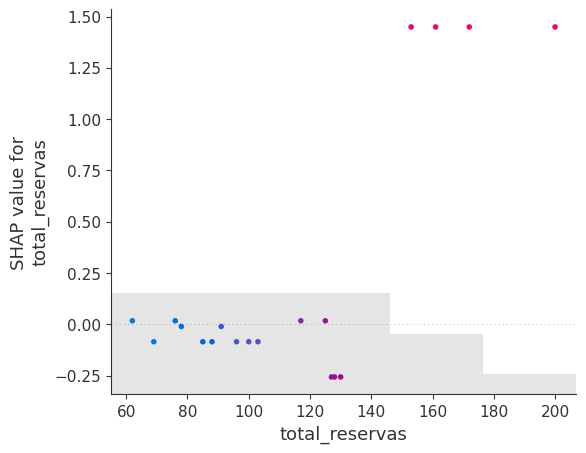

In [6]:
# Plot de Dependência para a variável mais forte (total_reservas)
if "total_reservas" in top_5_features:
    plt.title("Dependência: Total Reservas vs SHAP")
    shap.plots.scatter(shap_values[:,"total_reservas"], color=shap_values, show=False)
    plt.show()